<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/NLP/Natural_Language_Processing_Day_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

imdb_simple_rnn

In [61]:
# LSTM
from keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

In [62]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

In [63]:
print("Training samples:",len(x_train))
print("Testing samples:" ,len(x_test))
print("First review (encoded):", x_train[0])
print("length of first review",len(x_train[0]))
print("First review label:",y_train[0])

Training samples: 25000
Testing samples: 25000
First review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19

In [64]:
# Decode a review back to words (optional)
word_index = imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index[0] = '[PAD]'
reverse_index[1] = '[START]'
reverse_index[2] = '[OOV]'

decoded = ' '.join(reverse_index.get(i, '?') for i in x_train[0])
print(decoded[:120])  # "this film was just brilliant casting ..."
print('Label:', y_train[0])  # 1 = positive

[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they pla
Label: 1


In [65]:
# limit reviews to 200 words

x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)


In [66]:
print(x_train[2])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    1   14   47    8   30   31    7    4  249  108    7
    4 5974   54   61  369   13   71  149   14   22  112    4 2401  311
   12   16 3711   33   75   43 1829  296    4   86  320   35  534   19
  263 4821 1301    4 1873   33   89   78   12   66   16    4  360    7
    4   58  316  334   11    4 1716   43  645  662    8  257   85 1200
   42 1228 2578   83   68 3912   15   36  165 1539  278   36   69    2
  780    8  106   14 6905 1338   18    6   22   12  215   28  610   40
    6   87  326   23 2300   21   23   22   12  272   40   57   31   11
    4   22   47    6 2307   51    9  170   23  595  116  595 1352   13
  191   79  638   89    2   14    9    8  106  607  624   35  534    6
  227 

In [67]:
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=200))  # Embedding layer
model.add(SimpleRNN(64,activation='tanh'))  # RNN with 64 units hidden state size is 64
model.add(Dense(1, activation='sigmoid'))  # Binary output


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile the Model

In [68]:
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=200))  # Embedding layer
model.add(SimpleRNN(64,activation='tanh'))  # RNN with 64 units hidden state size is 64
model.add(Dense(1, activation='sigmoid'))  # Binary output


In [69]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


Train the Model

In [70]:
history=model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6130 - loss: 0.6376 - val_accuracy: 0.7610 - val_loss: 0.5054
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8494 - loss: 0.3533 - val_accuracy: 0.8354 - val_loss: 0.3783
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9237 - loss: 0.2012 - val_accuracy: 0.8384 - val_loss: 0.4087
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9725 - loss: 0.0873 - val_accuracy: 0.8328 - val_loss: 0.4778
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9936 - loss: 0.0287 - val_accuracy: 0.8236 - val_loss: 0.5766


In [71]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:",test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8145 - loss: 0.6281
Test Accuracy: 0.8144800066947937


In [72]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [73]:
print(history.history['accuracy'])

[0.6129500269889832, 0.8494499921798706, 0.9237499833106995, 0.9725499749183655, 0.9935500025749207]


In [74]:
print(history.history['val_accuracy'])

[0.7609999775886536, 0.8353999853134155, 0.8384000062942505, 0.8327999711036682, 0.8235999941825867]


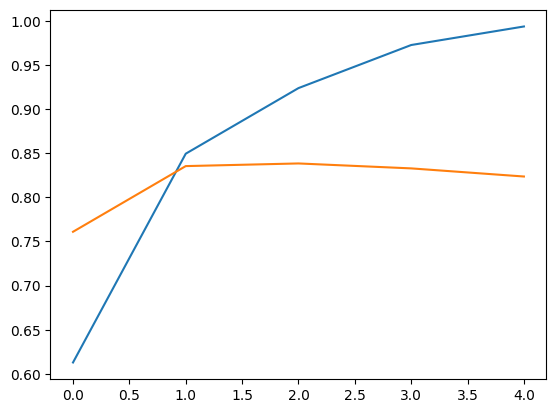

In [75]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Making prediction

In [76]:
sample_review = "This movie was fantastic! I loved the acting and story."

Preprocessing the Review for Prediction

In [77]:
word_index = imdb.get_word_index()

# Reserve space for special tokens
new_word_index = {}
for k, v in word_index.items():
    new_word_index[k] = v + 3 #reserve space for special tokens that are added to beginning
word_index = new_word_index
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2  # Unknown words
word_index["<UNUSED>"] = 3

# Create reverse index to decode indices to words

reverse_word_index = {}
for k, v in word_index.items():
    reverse_word_index[v] = k

In [78]:
def encode_review(review):
    tokens = review.lower().split()
    encoded = [1]  # <START>
    for word in tokens:
        if word in word_index:
            encoded.append(word_index[word])
        else:
            encoded.append(2)  # <UNK>
    return encoded

sample_review = "This movie was fantastic! I loved the acting and story."
encoded_review = encode_review(sample_review)
padded_review = pad_sequences([encoded_review], maxlen=200)

prediction = model.predict(padded_review)[0][0]
if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
Negative Review


In [79]:
from keras.layers import Dropout

model_earlystop = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    SimpleRNN(64,
    dropout=0.3,
    recurrent_dropout=0.3),
    Dense(1,activation='sigmoid')
])

In [80]:
model_earlystop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [81]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

x_train_processed = pad_sequences(x_train, maxlen=200, dtype='int32')
y_train_processed = np.array(y_train, dtype='int32')
history1=model_earlystop.fit(x_train_processed, y_train_processed, epochs=10, batch_size=128, validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5009 - loss: 0.7198 - val_accuracy: 0.5176 - val_loss: 0.6898
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5159 - loss: 0.6988 - val_accuracy: 0.5376 - val_loss: 0.6885
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5209 - loss: 0.6952 - val_accuracy: 0.5498 - val_loss: 0.6878
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5354 - loss: 0.6891 - val_accuracy: 0.5586 - val_loss: 0.6832
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5387 - loss: 0.6895 - val_accuracy: 0.5534 - val_loss: 0.6826
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5436 - loss: 0.6859 - val_accuracy: 0.5466 - val_loss: 0.6818
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5555 - loss: 0.6820 - val_accuracy: 0.5490 - val_loss: 0.6801
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5520 - loss: 0.6806 - val_accu

In [82]:
x_test_processed = pad_sequences(x_test, maxlen=200, dtype='int32')
y_test_processed = np.array(y_test, dtype='int32')
test_loss_earlystop, test_accuracy_earlystop= model_earlystop.evaluate(x_test_processed, y_test_processed)
print("Test Accuracy (with earlystop):", test_accuracy_earlystop)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5517 - loss: 0.6787
Test Accuracy (with earlystop): 0.5517200231552124


In [83]:
print(history1.history['accuracy'])
print(history1.history['val_accuracy'])

[0.5008500218391418, 0.5158500075340271, 0.5208500027656555, 0.5354499816894531, 0.5386999845504761, 0.5435500144958496, 0.5554500222206116, 0.552049994468689, 0.5603500008583069, 0.5573999881744385]
[0.5175999999046326, 0.5375999808311462, 0.5497999787330627, 0.5586000084877014, 0.5533999800682068, 0.5465999841690063, 0.5490000247955322, 0.5460000038146973, 0.5460000038146973, 0.5401999950408936]


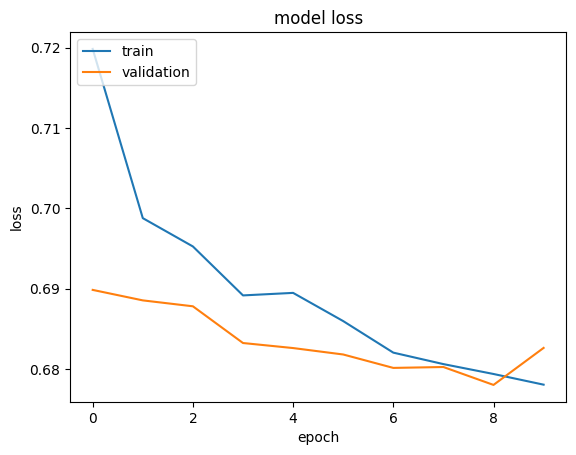

In [84]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

housing_base

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [86]:
df = pd.read_csv('/content/drive/MyDrive/CDAC/housing.csv')
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [87]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [88]:
# Drop missing values
df.dropna(inplace=True)

# Encode categorical column
df = pd.get_dummies(df, columns=['ocean_proximity'])

# Separate features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Feature columns:", list(X.columns))
print("Dataset shape after preprocessing:", X.shape)

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Dataset shape after preprocessing: (20433, 13)


In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [90]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # transform test

In [91]:
model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                              input_shape=(13,)),

        tf.keras.layers.Dense(64, activation='relu'),



        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

In [93]:
history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=1)

Epoch 1/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 44905668608.0000 - mae: 179000.0781 - val_loss: 15228849152.0000 - val_mae: 92351.1328
Epoch 2/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8870982656.0000 - mae: 69037.7344 - val_loss: 7827152896.0000 - val_mae: 63379.7539
Epoch 3/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6611746816.0000 - mae: 58123.2461 - val_loss: 6511491584.0000 - val_mae: 56416.6211
Epoch 4/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5710848512.0000 - mae: 53430.3711 - val_loss: 5737717248.0000 - val_mae: 53304.8320
Epoch 5/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5235381760.0000 - mae: 51141.6172 - val_loss: 5360004608.0000 - val_mae: 51817.0508
Epoch 6/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4971630080.0000 - mae: 50076.9297 - val_loss: 5139704320.0000 - val_mae: 50704.2539
Epoch 7/200
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4815618048.0000 - mae: 49198.9297 - val_loss: 5000723968.0000 - va

In [94]:
y_pred = model.predict(X_test_sc).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
r2   = r2_score(y_test, y_pred)


print( "MAE:",mae)
print("RMSE:",rmse)
print("R² :",r2)


128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MAE: 40753.328125
RMSE: 59386.8475314097
R² : 0.7421022653579712


Text(0.5, 1.0, 'Training & Validation Loss')

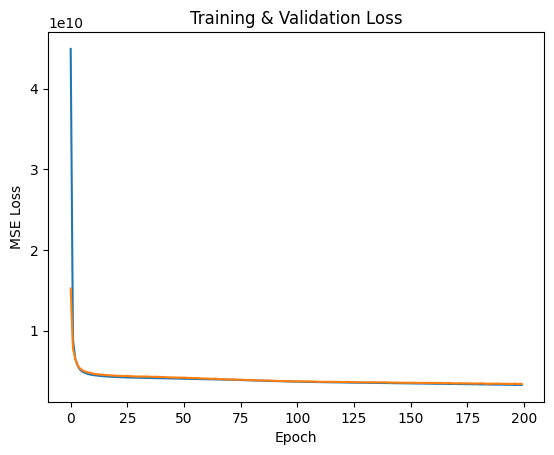

In [95]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')